# Task 8 — Business-question visualizations

**Problem-statement step — use appropriate visualisation to analyse:**
1. Top-performing and lowest-revenue products.
2. Correlation between customers' age and acceptance of the last campaign.
3. Country with the most customers who accepted the last campaign.
4. Pattern between number of children at home and total expenditure.
5. Educational background of customers who complained in the last 2 years.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Locate the raw data whether the notebook is opened from its own folder
# (notebooks/) or from the project root.
import os
_CANDIDATES = ["marketing_data.csv", "../marketing_data.csv",
               os.path.join(os.path.dirname(os.getcwd()), "marketing_data.csv")]
DATA_PATH = next((p for p in _CANDIDATES if os.path.exists(p)), "marketing_data.csv")
print("Using data file:", DATA_PATH)

Using data file: ../marketing_data.csv


In [2]:
REFERENCE_YEAR = 2015  # data compiled just after the last enrolment (Jun 2014)
SPEND_COLS = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
CHANNEL_COLS = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

def load_and_prepare(path=DATA_PATH, engineer=True):
    """Load -> fix dtypes -> clean categories -> impute income -> features."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()                     # ' Income ' -> 'Income'
    if not pd.api.types.is_numeric_dtype(df["Income"]):     # '$84,835.00' -> float
        df["Income"] = (df["Income"].astype("string")
                        .str.replace(r"[\$,]", "", regex=True).str.strip().astype(float))
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%y")
    df["Marital_Status"] = df["Marital_Status"].replace(
        {"Alone": "Single", "YOLO": "Single", "Absurd": "Single"})
    df["Income"] = df.groupby(["Education", "Marital_Status"])["Income"].transform(
        lambda s: s.fillna(s.median()))
    df["Income"] = df["Income"].fillna(df["Income"].median())
    if engineer:
        df["Kids"] = df["Kidhome"] + df["Teenhome"]
        df["Age"] = REFERENCE_YEAR - df["Year_Birth"]
        df["Total_Spending"] = df[SPEND_COLS].sum(axis=1)
        df["Total_Purchases"] = df[CHANNEL_COLS].sum(axis=1)
        df["Total_Accepted_Cmp"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                                       "AcceptedCmp4", "AcceptedCmp5"]].sum(axis=1)
        df["Has_Child"] = (df["Kids"] > 0).astype(int)
        df["Is_US"] = (df["Country"] == "US").astype(int)
    return df

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

def treat_outliers(df):
    """Drop impossible ages and winsorise heavy-tailed continuous columns."""
    df = df[df["Age"] <= 100].copy()
    for col in ["Income", "Total_Spending", "Total_Purchases", "NumWebVisitsMonth"]:
        lo, hi = iqr_bounds(df[col])
        df[col] = df[col].clip(lo, hi)
    return df

In [3]:
from scipy import stats
df = treat_outliers(load_and_prepare())
LABELS = {"MntWines": "Wines", "MntFruits": "Fruits", "MntMeatProducts": "Meat",
          "MntFishProducts": "Fish", "MntSweetProducts": "Sweets", "MntGoldProds": "Gold"}

## 8.1 Top and bottom revenue products

Fruits     58767
Sweets     60553
Fish       83939
Gold       98358
Meat      373393
Wines     680038
dtype: int64


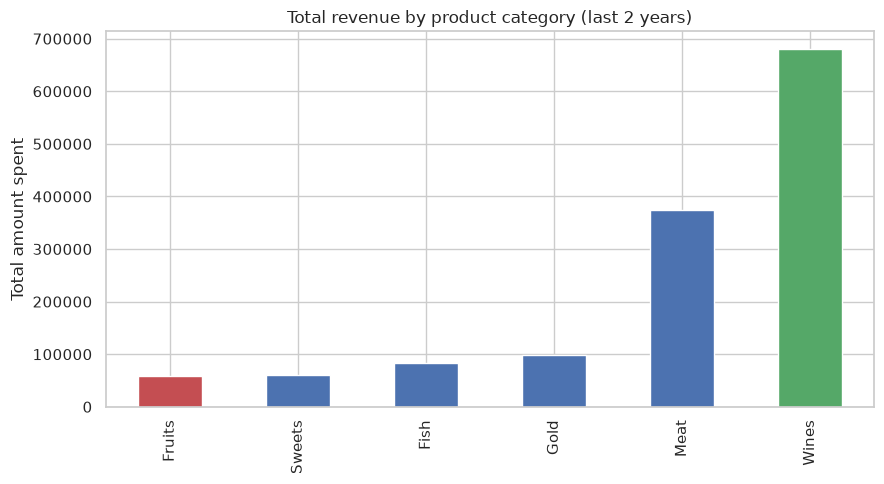

In [4]:
revenue = df[SPEND_COLS].sum().rename(index=LABELS).sort_values()
print(revenue)
colors = ["#C44E52" if v == revenue.min() else "#55A868" if v == revenue.max() else "#4C72B0"
          for v in revenue.values]
ax = revenue.plot(kind="bar", figsize=(9, 5), color=colors)
ax.set_title("Total revenue by product category (last 2 years)")
ax.set_ylabel("Total amount spent"); plt.tight_layout(); plt.show()

**Wines** and **Meat** dominate revenue; **Fruits** and **Sweets** are the smallest lines.

## 8.2 Age vs acceptance of the last campaign

Point-biserial corr(Age, Response) = -0.018 (p = 0.384)
Mean age  accepted = 45.6 | not = 46.2


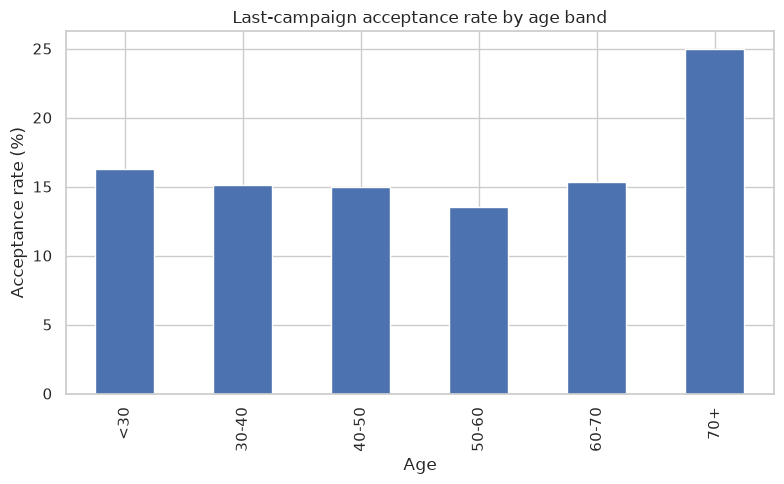

In [5]:
r, p = stats.pointbiserialr(df["Response"], df["Age"])
print(f"Point-biserial corr(Age, Response) = {r:+.3f} (p = {p:.3f})")
print("Mean age  accepted =", round(df.loc[df.Response==1, "Age"].mean(), 1),
      "| not =", round(df.loc[df.Response==0, "Age"].mean(), 1))
bands = pd.cut(df["Age"], [0, 30, 40, 50, 60, 70, 120],
               labels=["<30", "30-40", "40-50", "50-60", "60-70", "70+"])
rate = df.groupby(bands, observed=True)["Response"].mean() * 100
ax = rate.plot(kind="bar", figsize=(8, 5), color="#4C72B0")
ax.set_title("Last-campaign acceptance rate by age band"); ax.set_ylabel("Acceptance rate (%)")
plt.tight_layout(); plt.show()

Age is essentially **uncorrelated** with acceptance — the rate is flat across age bands.

## 8.3 Country with the most campaign accepters

Country
SP     176
SA      52
CA      38
AUS     23
GER     17
IND     13
US      13
ME       2
Name: count, dtype: int64


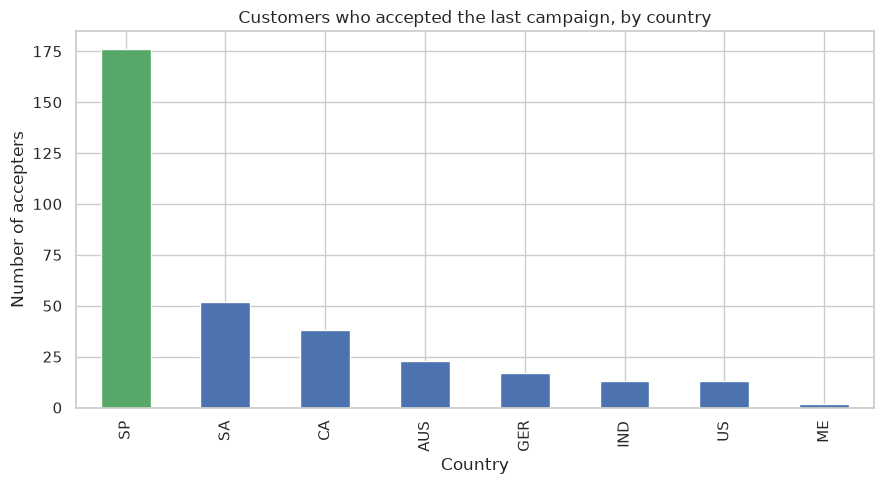

In [6]:
accepted = df[df["Response"] == 1]["Country"].value_counts()
print(accepted)
top = accepted.idxmax()
colors = ["#55A868" if c == top else "#4C72B0" for c in accepted.index]
ax = accepted.plot(kind="bar", figsize=(9, 5), color=colors)
ax.set_title("Customers who accepted the last campaign, by country")
ax.set_ylabel("Number of accepters"); plt.tight_layout(); plt.show()

**Spain (SP)** has by far the most accepters — it is also the largest customer base.

## 8.4 Number of children vs total expenditure

Kids
0    1105.0
1     473.0
2     246.0
3     275.0
Name: Total_Spending, dtype: float64


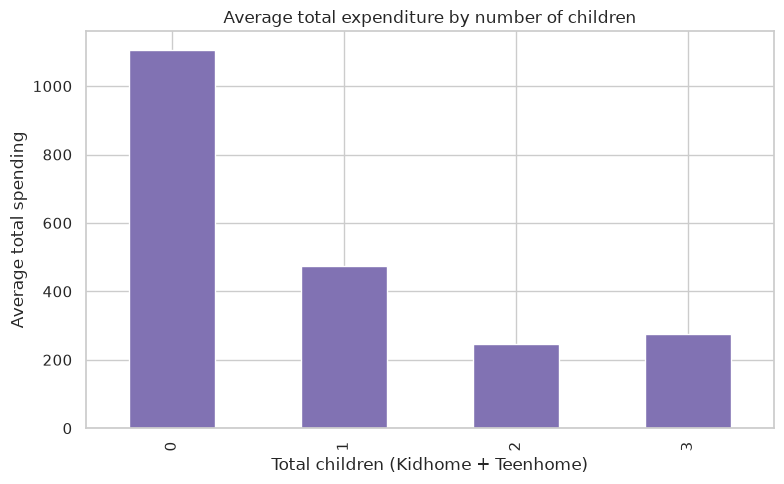

In [7]:
spend_by_kids = df.groupby("Kids")["Total_Spending"].mean()
print(spend_by_kids.round(0))
ax = spend_by_kids.plot(kind="bar", figsize=(8, 5), color="#8172B3")
ax.set_title("Average total expenditure by number of children")
ax.set_xlabel("Total children (Kidhome + Teenhome)"); ax.set_ylabel("Average total spending")
plt.tight_layout(); plt.show()

Spending **falls** as the number of children rises — clear downward pattern.

## 8.5 Education of customers who complained (last 2 years)

Education
Graduation    14
2n Cycle       3
Master         2
PhD            1
Name: count, dtype: int64
Total complainers: 20


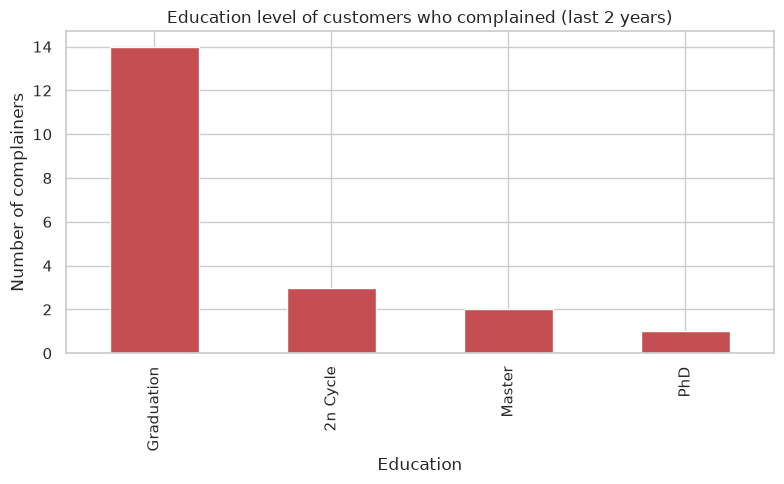

In [8]:
complainers = df[df["Complain"] == 1]["Education"].value_counts()
print(complainers)
print("Total complainers:", int(df["Complain"].sum()))
ax = complainers.plot(kind="bar", figsize=(8, 5), color="#C44E52")
ax.set_title("Education level of customers who complained (last 2 years)")
ax.set_ylabel("Number of complainers"); plt.tight_layout(); plt.show()

Complaints are rare (~20) and concentrated in the largest segment, `Graduation`.

### Conclusion
Wines & Meat drive revenue; age is unrelated to campaign acceptance; Spain leads on accepters; spending declines with more children; and complaints are few and spread across education levels.